# Multi-Class Brain Tumor Classification Using Convolutional Neural Networks


## Deployment Setup Instructions

 - The file "index.html" needs to be moved to the subfolder `./templates/index.html`

Note that you will have to interrupt the kernel or Jupyter to stop the web server execution.

## Data set

https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset/data

Import neccesary packages

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras import optimizers
from tensorflow.keras import layers, Input, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

/opt/anaconda3/envs/CSCIE-89/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Getting and preparing the data

In [3]:
import zipfile

local_zip = './Brain MRI Dataset.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall()
zip_ref.close()

In [4]:
# Directory with our testing pictures
classes = ['glioma', 'meningioma', 'pituitary', 'notumor']
n_classes = len(classes)
df = pd.DataFrame()
for c in classes:
    test = os.path.join('.', 'Testing', c)
    test_fnames = os.listdir(test)
    test_fnames = [os.path.join(test, x) for x in test_fnames]

    print(f'total {c} images :', len(test_fnames))
    print(test_fnames[:3])

    test_df = pd.DataFrame({'file': test_fnames, 'label':c})
    df = pd.concat([df, test_df])


total glioma images : 300
['./Testing/glioma/Te-gl_0284.jpg', './Testing/glioma/Te-gl_0290.jpg', './Testing/glioma/Te-gl_0247.jpg']
total meningioma images : 306
['./Testing/meningioma/Te-me_0304.jpg', './Testing/meningioma/Te-me_0106.jpg', './Testing/meningioma/Te-meTr_0004.jpg']
total pituitary images : 300
['./Testing/pituitary/Te-pi_0233.jpg', './Testing/pituitary/Te-pi_0227.jpg', './Testing/pituitary/Te-pi_0019.jpg']
total notumor images : 405
['./Testing/notumor/Te-no_0051.jpg', './Testing/notumor/Te-no_0045.jpg', './Testing/notumor/Te-no_0079.jpg']


In [5]:
# Directory with our training pictures
classes = ['glioma', 'meningioma', 'pituitary', 'notumor']
n_classes = len(classes)
train = pd.DataFrame()
for c in classes:
    train_path = os.path.join('.', 'Training', c)
    train_fnames = os.listdir(train_path)
    train_fnames = [os.path.join(train_path, x) for x in train_fnames]

    print(f'total {c} images :', len(train_fnames))
    print(train_fnames[:3])

    train_df = pd.DataFrame({'file': train_fnames, 'label':c})
    train = pd.concat([train, train_df])

# Shuffle the dataframe
train.reset_index(inplace=True, drop=True)
train = train.sample(frac=1, random_state=seed)

print(train)
train.info()


total glioma images : 1321
['./Training/glioma/Tr-gl_1135.jpg', './Training/glioma/Tr-gl_0559.jpg', './Training/glioma/Tr-gl_1121.jpg']
total meningioma images : 1339
['./Training/meningioma/Tr-me_0368.jpg', './Training/meningioma/Tr-me_1076.jpg', './Training/meningioma/Tr-me_1062.jpg']
total pituitary images : 1457
['./Training/pituitary/Tr-pi_0505.jpg', './Training/pituitary/Tr-pi_0263.jpg', './Training/pituitary/Tr-pi_0277.jpg']
total notumor images : 1595
['./Training/notumor/Tr-no_0798.jpg', './Training/notumor/Tr-no_1486.jpg', './Training/notumor/Tr-no_0940.jpg']
                                      file       label
1700  ./Training/meningioma/Tr-me_0041.jpg  meningioma
3269   ./Training/pituitary/Tr-pi_0159.jpg   pituitary
561       ./Training/glioma/Tr-gl_0267.jpg      glioma
5465     ./Training/notumor/Tr-no_1260.jpg     notumor
5460     ./Training/notumor/Tr-no_1248.jpg     notumor
...                                    ...         ...
3772   ./Training/pituitary/Tr-pi_1216.

In [6]:
# Shuffle the dataframe
train.reset_index(inplace=True, drop=True)
train = train.sample(frac=1, random_state=seed)

# Show how many values we have
print(len(train))
display(train.head(3))

# Split test data into validation/test
split_index = int(.8 * len(train))
validation = train.iloc[split_index:]
train = train.iloc[:split_index]

# Show our split
print('Validation set:')
print(validation['label'].value_counts())
display(validation.head(3))

print('Train set:')
print(train['label'].value_counts())
display(train.head(3))

test = df
print('Test set:')
print(test['label'].value_counts())
display(test.head(3))

5712


,file,label
1700,./Training/notumor/Tr-no_0480.jpg,notumor
3269,./Training/notumor/Tr-no_0589.jpg,notumor
561,./Training/glioma/Tr-gl_0074.jpg,glioma


Validation set:
label
notumor       318
meningioma    290
pituitary     288
glioma        247
Name: count, dtype: int64


,file,label
3190,./Training/pituitary/Tr-pi_0764.jpg,pituitary
4566,./Training/notumor/Tr-no_1339.jpg,notumor
5359,./Training/meningioma/Tr-me_0419.jpg,meningioma


Train set:
label
notumor       1277
pituitary     1169
glioma        1074
meningioma    1049
Name: count, dtype: int64


,file,label
1700,./Training/notumor/Tr-no_0480.jpg,notumor
3269,./Training/notumor/Tr-no_0589.jpg,notumor
561,./Training/glioma/Tr-gl_0074.jpg,glioma


Test set:
label
notumor       405
meningioma    306
glioma        300
pituitary     300
Name: count, dtype: int64


,file,label
0,./Testing/glioma/Te-gl_0284.jpg,glioma
1,./Testing/glioma/Te-gl_0290.jpg,glioma
2,./Testing/glioma/Te-gl_0247.jpg,glioma


In [7]:
# Directory with our training pictures
train = pd.DataFrame()
for c in classes:
    train_path = os.path.join('.', 'Training', c)
    train_fnames = os.listdir(train_path)
    train_fnames = [os.path.join(train_path, x) for x in train_fnames]

    print(f'total {c} images :', len(train_fnames))
    print(train_fnames[:3])

    train_df = pd.DataFrame({'file': train_fnames, 'label':c})
    train = pd.concat([train, train_df])

# Shuffle the dataframe
train.reset_index(inplace=True, drop=True)
train = train.sample(frac=1, random_state=seed)

print(train)
train.info()


total glioma images : 1321
['./Training/glioma/Tr-gl_1135.jpg', './Training/glioma/Tr-gl_0559.jpg', './Training/glioma/Tr-gl_1121.jpg']
total meningioma images : 1339
['./Training/meningioma/Tr-me_0368.jpg', './Training/meningioma/Tr-me_1076.jpg', './Training/meningioma/Tr-me_1062.jpg']
total pituitary images : 1457
['./Training/pituitary/Tr-pi_0505.jpg', './Training/pituitary/Tr-pi_0263.jpg', './Training/pituitary/Tr-pi_0277.jpg']
total notumor images : 1595
['./Training/notumor/Tr-no_0798.jpg', './Training/notumor/Tr-no_1486.jpg', './Training/notumor/Tr-no_0940.jpg']
                                      file       label
1700  ./Training/meningioma/Tr-me_0041.jpg  meningioma
3269   ./Training/pituitary/Tr-pi_0159.jpg   pituitary
561       ./Training/glioma/Tr-gl_0267.jpg      glioma
5465     ./Training/notumor/Tr-no_1260.jpg     notumor
5460     ./Training/notumor/Tr-no_1248.jpg     notumor
...                                    ...         ...
3772   ./Training/pituitary/Tr-pi_1216.

In [8]:
train_datagen = ImageDataGenerator(rescale=1./255,                         
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    x_col="file",
    y_col="label",
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical"
    )

val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_dataframe(
    dataframe=validation,
    x_col="file",
    y_col="label",
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical",
) 

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test,
    x_col="file",
    y_col="label",
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical",
) 


Found 5712 validated image filenames belonging to 4 classes.
Found 1143 validated image filenames belonging to 4 classes.
Found 1311 validated image filenames belonging to 4 classes.


# Build the CNN Model Architecture

In [9]:
# Define the model architecture
model = models.Sequential()
model.add(Input(shape=(150, 150, 3)))

# Convolutional layer 1
model.add(layers.Conv2D(32, (4, 4), activation="relu"))
model.add(layers.MaxPooling2D(pool_size=(3, 3)))

# Convolutional layer 2
model.add(layers.Conv2D(64, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D(pool_size=(3, 3)))

# Convolutional layer 3
model.add(layers.Conv2D(128, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D(pool_size=(2, 2))) #

# Convolutional layer 4
model.add(layers.Conv2D(128, (3, 3), activation="relu"))
model.add(layers.Flatten())

# Full connect layers
model.add(layers.Dense(512, activation="relu"))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(n_classes, activation="softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 147, 147, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,644 (4.93 MB)

 Trainable params: 1,292,644 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',  
    metrics=['accuracy']
)
# Callbacks for better training
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]
# Start model training
history = model.fit(
    train_generator,
    epochs=50,
    callbacks=callbacks,
    validation_data=val_generator,
    verbose=1
)

Epoch 1/50


/opt/anaconda3/envs/CSCIE-89/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.5431 - loss: 1.0121 - val_accuracy: 0.3220 - val_loss: 1.8299
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - accuracy: 0.6984 - loss: 0.7338 - val_accuracy: 0.7577 - val_loss: 0.6314
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.7672 - loss: 0.5852 - val_accuracy: 0.8259 - val_loss: 0.4983
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.7997 - loss: 0.5212 - val_accuracy: 0.8373 - val_loss: 0.4344
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - accuracy: 0.8398 - loss: 0.4296 - val_accuracy: 0.8679 - val_loss: 0.3528
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - accuracy: 0.8563 - loss: 0.3718 - val_accuracy: 0.8941 - val_loss: 0.2898
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - accuracy: 0.8824 - loss: 0.3178 - val_accuracy: 0.9256 - val_loss: 0.2175
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - accuracy: 0.8936 - loss: 0.2893 - val_accurac

In [11]:
# history = model.fit(
#     train_generator,
#     epochs=20,
#     callbacks=callbacks,
#     validation_data=val_generator,
#     verbose=1
# )

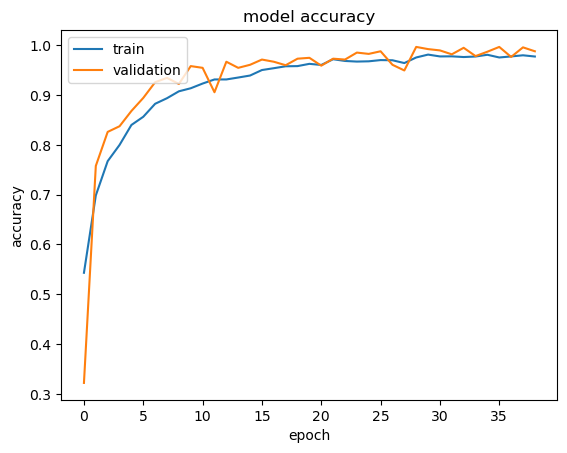

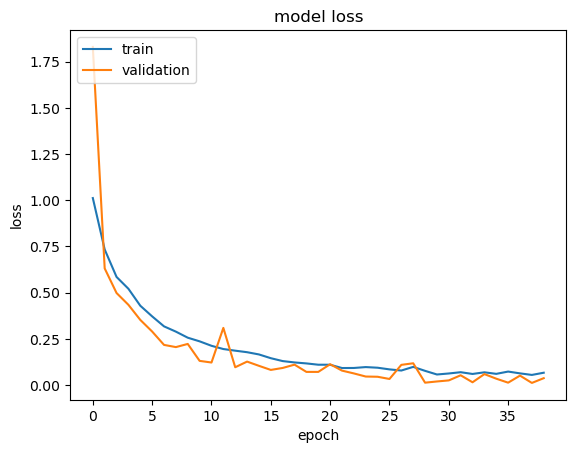

In [12]:
# "Accuracy"
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# "Loss"
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [13]:
# Finding best epoch and best val accuracy
best_epoch_ix = np.argmax(history.history['val_accuracy'])

best_val_acc = history.history['val_accuracy'][best_epoch_ix]

print("Best epoch", best_epoch_ix + 1)
print("Best validation accuracy", best_val_acc)

Best epoch 29
Best validation accuracy 0.9965004324913025


In [14]:
model.save("tumor_model.keras")

# Model Evaluation

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Reset generator and get predictions
test_generator.reset()
test_generator.shuffle = False

# Get predictions
test_predictions = model.predict(test_generator, verbose=1)
preds = np.argmax(test_predictions, axis=1)

# Get actual labels
actual_label = test_generator.classes

# Print classification report
labels = ['glioma', 'meningioma', 'pituitary', 'notumor']
print(classification_report(actual_label, preds, target_names=labels))

 3/41 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

/opt/anaconda3/envs/CSCIE-89/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.92      0.95       300
  meningioma       0.91      0.96      0.93       306
   pituitary       0.99      1.00      1.00       405
     notumor       0.98      0.98      0.98       300

    accuracy                           0.97      1311
   macro avg       0.97      0.96      0.96      1311
weighted avg       0.97      0.97      0.97      1311



## Confusion Matrix

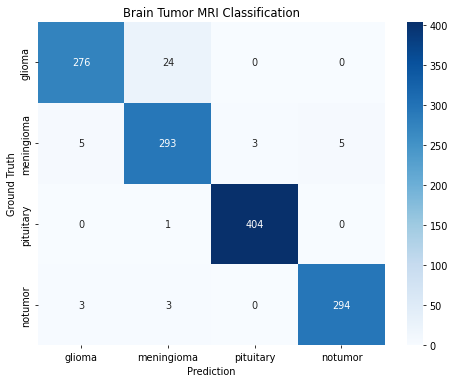

In [16]:
cnf = confusion_matrix(actual_label, preds)
plt.figure(figsize=(8,6), dpi=70, facecolor='w', edgecolor='k')
ax = sns.heatmap(cnf, cmap='Blues', annot=True, fmt = 'd', xticklabels=labels, yticklabels=labels)
plt.title('Brain Tumor MRI Classification')
plt.xlabel('Prediction')
plt.ylabel('Ground Truth')
plt.show(ax)

### Visual representations of actual vs predicted classifications

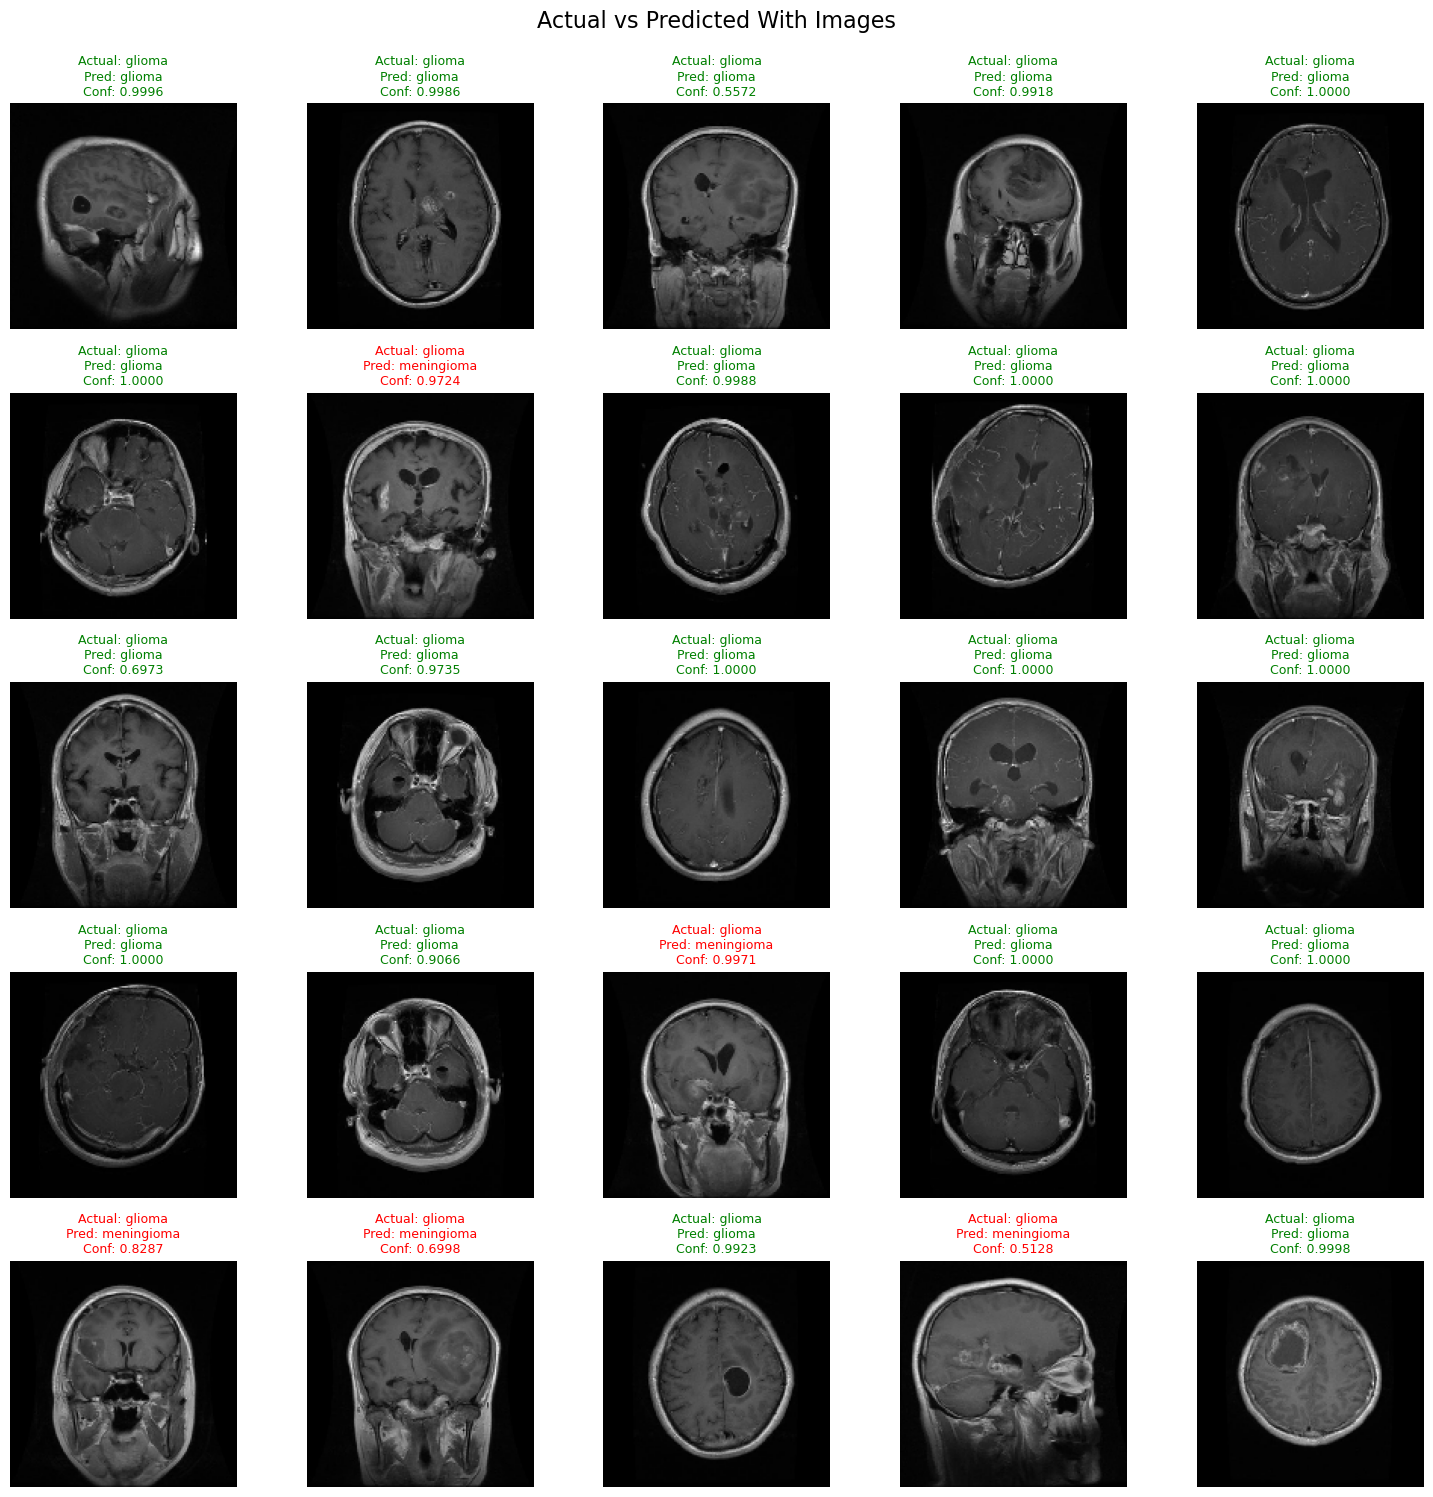

In [20]:
# Get the test images that will be displayed with their predicted value
# These are from the first "batch" (32 images)
batch_images, batch_labels = test_generator[0]

# Create grid
grid_width = 5
grid_height = 5
f, ax = plt.subplots(grid_width, grid_height, figsize=(15, 15))

for i in range(grid_width):
    for j in range(grid_height):
        img_idx = (i * grid_width) + j
        actual = actual_label[img_idx]
        predicted = preds[img_idx] # predicted class index (0 through 3)
        confidence = test_predictions[img_idx][predicted]
        
        # Color code: green if correct, red if wrong
        color = 'green' if actual == predicted else 'red'

        # Plot on the grid location i,j
        ax[i, j].axis('off')
        ax[i, j].set_title(
            f'Actual: {classes[actual]}\nPred: {classes[predicted]}\nConf: {confidence:.4f}',
            fontsize=9,
            color=color
        )
        ax[i, j].imshow(batch_images[img_idx])

plt.suptitle('Actual vs Predicted With Images', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

# Model Deployment

Using Flask for deployment.

In [10]:
from PIL import Image
import flask
import io

# Initialize Flask application
app = flask.Flask(__name__)

# Handle web traffic for GET and POST requests
@app.route("/", methods=["POST","GET"])
def handle_request():
    if flask.request.method == "GET":
        return flask.render_template('index.html')

    data = {}
    if flask.request.method == "POST":
        if flask.request.files.get("image"):
            classes = ['glioma', 'meningioma', 'pituitary', 'notumor']
       
            # Read the image from the request using PIL
            image = flask.request.files['image'].read()
            image = Image.open(io.BytesIO(image))
            
            # Preprocess the image and prepare it for classification
            image = prepare_image(image, target=(150, 150))

            # Classify the input image with the model (using the highest confidence prediction)
            # and prepare the result in data to return to the client
            preds = model.predict(image)
            predicted_class = np.argmax(preds, axis=1)[0]
            label = classes[predicted_class]                  

            data['predicted_tumor'] = label
            data['confidence'] = preds[0,predicted_class].astype(float)    
    
    return flask.jsonify(data)

def prepare_image(image, target):
    # Make sure image is in RGB mode
    if image.mode != "RGB":
        image = image.convert("RGB")

    # Preprocess the image data
    # Resize the input image to the target shape, normalize pixel values
    image = image.resize(target)
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    image = image.astype('float32')
    image = image / 255
 
    return image

# Start running the server
if __name__ == "__main__":
    print('Deploying server & loading DL model... this might take a few seconds!')
    global model
    model = load_model('tumor_model.keras')
    app.run(port=8000)

Deploying server & loading DL model... this might take a few seconds!
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:8000
Press CTRL+C to quit
